# 하이퍼 파라미터 튜닝
- train 데이터를 분할한 validation 데이터를 통해 하이퍼 파라미터 탐색 및 결정

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from datasets.mnist import load_mnist
from b1.utils import shuffle_dataset


(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

# 결과를 빠르게 얻기 위해 훈련 데이터를 줄임
x_train = x_train[:500]
t_train = t_train[:500]

# 20%를 검증 데이터로 분할
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)
x_train, t_train = shuffle_dataset(x_train, t_train)
x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]

In [ ]:
from b1.module.multi_layer_net import MultiLayerNet
from b1.module.trainer import Trainer

def __train(lr, weight_decay, epocs=50):
    network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                            output_size=10, weight_decay_lambda=weight_decay)
    trainer = Trainer(network, x_train, t_train, x_val, t_val,
                      epochs=epocs, mini_batch_size=100,
                      optimizer='sgd', optimizer_param={'lr': lr}, verbose=False)
    trainer.train()

    return trainer.test_acc_list, trainer.train_acc_list

In [5]:
optimization_trial = 100
results_val = {}
results_train = {}
for _ in range(optimization_trial):
    weight_decay = 10 ** np.random.uniform(-8, -4)
    lr = 10 ** np.random.uniform(-6, -2)

    val_acc_list, train_acc_list = __train(lr, weight_decay)
    print("val acc:" + str(val_acc_list[-1]) + " | lr:" + str(lr) + ", weight decay:" + str(weight_decay))
    key = "lr:" + str(lr) + ", weight decay:" + str(weight_decay)
    results_val[key] = val_acc_list
    results_train[key] = train_acc_list

val acc:0.15 | lr:0.000665205602854686, weight decay:1.4688408903491983e-08
val acc:0.74 | lr:0.00977631234932673, weight decay:1.9842378674525008e-07
val acc:0.12 | lr:1.1798517843581658e-05, weight decay:4.979893169468286e-07
val acc:0.09 | lr:3.2422856749883394e-06, weight decay:4.0670576102656274e-07
val acc:0.08 | lr:0.00015951003047605963, weight decay:1.249929937229344e-07
val acc:0.1 | lr:1.8441515860089717e-05, weight decay:8.828456418540065e-05
val acc:0.11 | lr:3.001850041694777e-06, weight decay:2.8073217165150826e-06
val acc:0.07 | lr:2.1719740579490192e-05, weight decay:1.61313067153941e-08
val acc:0.27 | lr:0.0007138745551403146, weight decay:3.908012029025587e-06
val acc:0.27 | lr:0.0011967737963987355, weight decay:3.2094990609189254e-07
val acc:0.73 | lr:0.00753233123282821, weight decay:6.169246077755266e-06
val acc:0.71 | lr:0.008375683583866075, weight decay:2.300758458289257e-06
val acc:0.07 | lr:3.8164301719425205e-06, weight decay:1.5999699895976385e-08
val acc:

Best-1(val acc:0.74) | lr:0.00977631234932673, weight decay:1.9842378674525008e-07
Best-2(val acc:0.73) | lr:0.00753233123282821, weight decay:6.169246077755266e-06
Best-3(val acc:0.71) | lr:0.008375683583866075, weight decay:2.300758458289257e-06
Best-4(val acc:0.71) | lr:0.009499539403778337, weight decay:1.9196675179983622e-05
Best-5(val acc:0.65) | lr:0.008068982289547423, weight decay:4.912840720041803e-05
Best-6(val acc:0.64) | lr:0.007252541642755312, weight decay:1.0480227938235648e-08
Best-7(val acc:0.59) | lr:0.005093319183983759, weight decay:8.283724337922495e-08
Best-8(val acc:0.52) | lr:0.003817896173156409, weight decay:2.0870307408200513e-08
Best-9(val acc:0.5) | lr:0.0036206085627075906, weight decay:9.036219879555938e-08
Best-10(val acc:0.47) | lr:0.003201490693479983, weight decay:4.872886945795801e-08
Best-11(val acc:0.42) | lr:0.0031824374208059138, weight decay:2.3335219941764862e-06
Best-12(val acc:0.4) | lr:0.001792575000300434, weight decay:8.083482118738314e-0

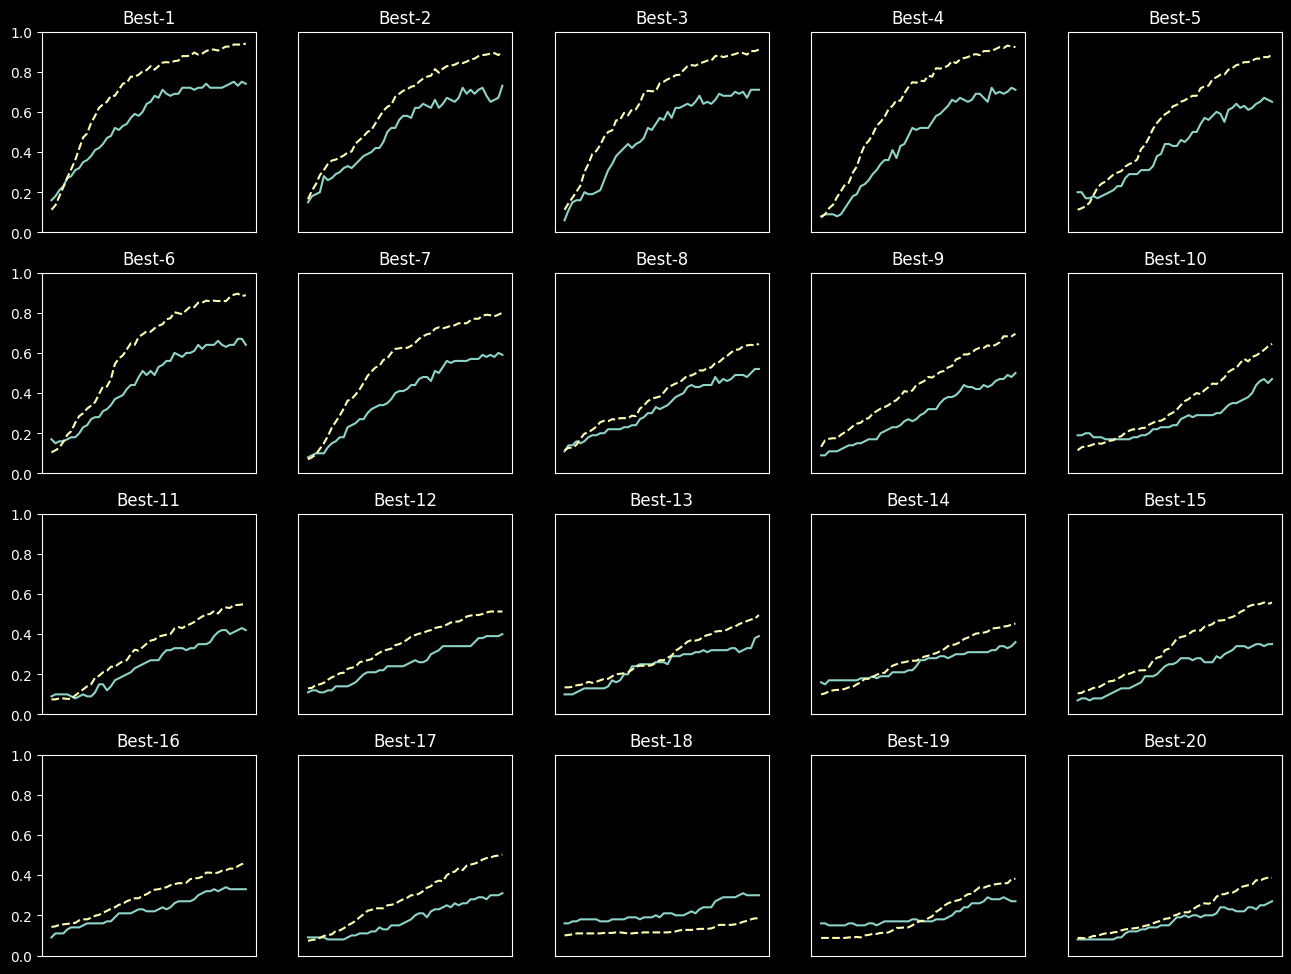

In [7]:
graph_draw_num = 20
col_num = 5
row_num = int(np.ceil(graph_draw_num / col_num))
i = 0

plt.figure(figsize=(16, 12))
for key, val_acc_list in sorted(results_val.items(), key=lambda x:x[1][-1], reverse=True):
    print("Best-" + str(i+1) + "(val acc:" + str(val_acc_list[-1]) + ") | " + key)

    plt.subplot(row_num, col_num, i+1)
    plt.title("Best-" + str(i+1))
    plt.ylim(0.0, 1.0)
    if i % 5: plt.yticks([])
    plt.xticks([])
    x = np.arange(len(val_acc_list))
    plt.plot(x, val_acc_list)
    plt.plot(x, results_train[key], "--")
    i += 1

    if i >= graph_draw_num:
        break

plt.show()

In [8]:
optimization_trial = 100
results_val = {}
results_train = {}
for _ in range(optimization_trial):
    weight_decay = 10 ** np.random.uniform(-8, -6)
    lr = 10 ** np.random.uniform(-3, -2)

    val_acc_list, train_acc_list = __train(lr, weight_decay)
    print("val acc:" + str(val_acc_list[-1]) + " | lr:" + str(lr) + ", weight decay:" + str(weight_decay))
    key = "lr:" + str(lr) + ", weight decay:" + str(weight_decay)
    results_val[key] = val_acc_list
    results_train[key] = train_acc_list

val acc:0.65 | lr:0.006376321274290691, weight decay:1.7970455230677172e-08
val acc:0.75 | lr:0.007145385987452444, weight decay:3.679936814363379e-07
val acc:0.73 | lr:0.005411663106686104, weight decay:1.1720628802824495e-07
val acc:0.51 | lr:0.004471831475287257, weight decay:3.011215334963841e-08
val acc:0.62 | lr:0.004671592477679606, weight decay:3.9225671166833774e-08
val acc:0.32 | lr:0.0025004858717102008, weight decay:2.947373665003494e-07
val acc:0.54 | lr:0.003470503633852284, weight decay:2.2465142673772104e-07
val acc:0.44 | lr:0.00262320726282196, weight decay:3.461162843552866e-08
val acc:0.68 | lr:0.00803150000263782, weight decay:1.1610922247416856e-07
val acc:0.74 | lr:0.009144834219904231, weight decay:2.251711916907112e-08
val acc:0.55 | lr:0.003982500102349893, weight decay:3.3901395692718596e-08
val acc:0.42 | lr:0.0028576688430449596, weight decay:6.879627377444364e-08
val acc:0.21 | lr:0.0012714594441363453, weight decay:5.524194712698054e-07
val acc:0.67 | lr:

Best-1(val acc:0.77) | lr:0.009570727294332438, weight decay:3.65838281160602e-08
Best-2(val acc:0.77) | lr:0.007945640421418725, weight decay:7.337681269104584e-08
Best-3(val acc:0.75) | lr:0.007145385987452444, weight decay:3.679936814363379e-07
Best-4(val acc:0.74) | lr:0.009144834219904231, weight decay:2.251711916907112e-08
Best-5(val acc:0.73) | lr:0.005411663106686104, weight decay:1.1720628802824495e-07
Best-6(val acc:0.73) | lr:0.008120326148845534, weight decay:7.152425279545715e-07
Best-7(val acc:0.73) | lr:0.009134454730823536, weight decay:2.1780599777185813e-08
Best-8(val acc:0.72) | lr:0.009565195932246988, weight decay:1.2950323258927176e-07
Best-9(val acc:0.72) | lr:0.008322823240775984, weight decay:7.272798199147067e-07
Best-10(val acc:0.72) | lr:0.0059252719313286125, weight decay:1.578415261838848e-08
Best-11(val acc:0.71) | lr:0.008938497016437596, weight decay:7.379471975517286e-07
Best-12(val acc:0.69) | lr:0.008413601554153098, weight decay:4.336287661361406e-0

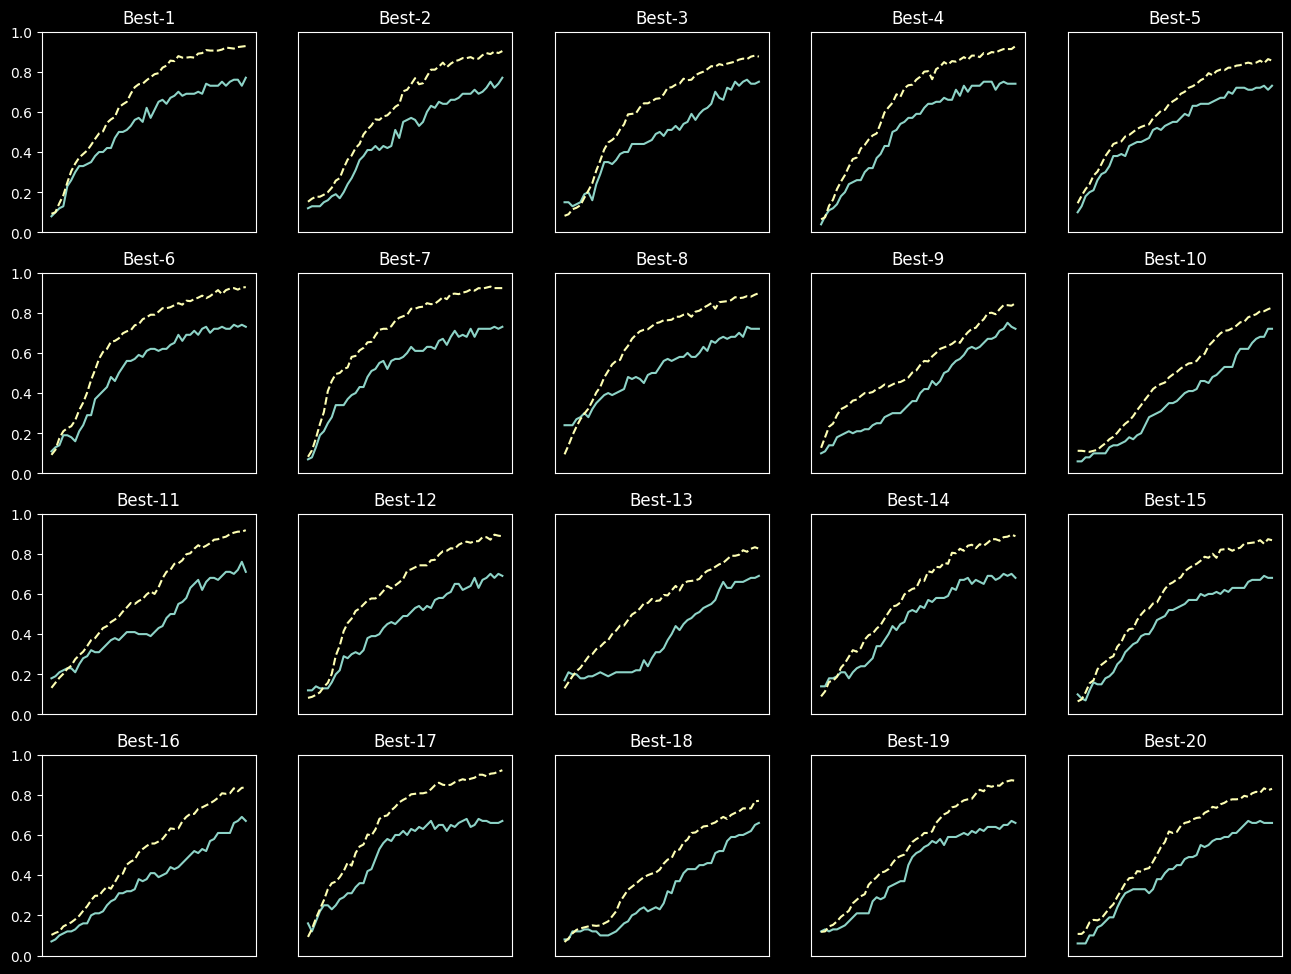

In [9]:
graph_draw_num = 20
col_num = 5
row_num = int(np.ceil(graph_draw_num / col_num))
i = 0

plt.figure(figsize=(16, 12))
for key, val_acc_list in sorted(results_val.items(), key=lambda x:x[1][-1], reverse=True):
    print("Best-" + str(i+1) + "(val acc:" + str(val_acc_list[-1]) + ") | " + key)

    plt.subplot(row_num, col_num, i+1)
    plt.title("Best-" + str(i+1))
    plt.ylim(0.0, 1.0)
    if i % 5: plt.yticks([])
    plt.xticks([])
    x = np.arange(len(val_acc_list))
    plt.plot(x, val_acc_list)
    plt.plot(x, results_train[key], "--")
    i += 1

    if i >= graph_draw_num:
        break

plt.show()